In [43]:
import pandas as pd
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
import numpy as np
import shap
import matplotlib.pyplot as plt
import re
import json

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

### Hurricane

In [44]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Hurricane_Regression_data.csv")  # Adjust path if needed

In [45]:
df.head()

,Unnamed: 0,FIPS,NMR,Hurricane_Frequency,Hurricane_Loss,Hurricane_Fatalities,Hurricane_Injuries,%BelowPoverty,%Unemployed,PerCapitaIncome,...,%HousePop>Room,%NoVehicleHH,%GroupQuarters,Pop Density,Unaffordability,MedianHHIncome2000,%ChangeIncome,Income/Value2000,%Income/%Value,Amenity Scale
0,0,1001,5.813354,0.000000,-0.131227,0.0,0.0,-0.704653,-0.577724,0.590676,...,-0.511788,-0.340506,-0.315717,0.139450,0.328723,0.916988,-0.604567,0.167626,-1.175420,0.352071
1,1,1003,22.393108,0.666667,-0.060062,0.0,0.0,-0.545471,-0.486589,0.852297,...,-0.126170,-0.807268,-0.194921,0.267396,0.042245,0.758613,0.130630,-0.967496,0.039616,0.967456
2,2,1005,-7.284080,0.000000,-0.140228,0.0,0.0,0.709418,0.295602,-0.605677,...,-0.169993,0.874858,2.649279,-0.201740,0.061277,-0.602092,-0.538458,-0.597719,0.534885,0.002959
3,3,1007,1.336304,0.000000,-0.109714,0.0,0.0,-0.503410,0.177946,-0.049269,...,-0.573847,-0.330483,2.122169,-0.169192,-0.725820,-0.034514,0.663615,-0.050233,-1.266429,-0.198225
4,4,1009,5.568893,-0.333333,-0.141615,0.0,0.0,-0.431575,-0.236991,0.109272,...,0.303601,-0.781960,-0.310226,0.123176,-0.089797,0.308711,-0.565885,-0.200569,-3.463433,0.026627


### Without Disaster Variables

In [46]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 02:05:53] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 02:05:53] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 02:05:53] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 02:05:53] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 02:05:53] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 02:05:53] {2393} INFO - Estimated sufficient time budget=4285s. Estimated necessary time budget=23s.
[flaml.automl.logger: 06-03 02:05:53] {2442} INFO -  at 0.5s,	estimator xgboost's best error=8.8882,	best estimator xgboost's best error=8.8882
[flaml.automl.logger: 06-03 02:05:53] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 02:05:53] {2442} INFO -  at 0.8s,	estimator lgbm's best error=8.8714,	best estimator lgbm's best error=8.8714
[flaml.automl.logger:

[flaml.automl.logger: 06-03 02:06:04] {2442} INFO -  at 10.9s,	estimator rf's best error=7.0201,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:04] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 02:06:04] {2442} INFO -  at 11.3s,	estimator histgb's best error=5.8011,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:04] {2258} INFO - iteration 35, current learner rf
[flaml.automl.logger: 06-03 02:06:05] {2442} INFO -  at 12.3s,	estimator rf's best error=6.6494,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:05] {2258} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 06-03 02:06:05] {2442} INFO -  at 12.7s,	estimator lgbm's best error=6.7070,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:05] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 02:06:06] {2442} INFO -  at 13.0s,	estimator histgb's best e

[flaml.automl.logger: 06-03 02:06:34] {2258} INFO - iteration 69, current learner lgbm
[flaml.automl.logger: 06-03 02:06:36] {2442} INFO -  at 43.6s,	estimator lgbm's best error=5.9098,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:36] {2258} INFO - iteration 70, current learner rf
[flaml.automl.logger: 06-03 02:06:37] {2442} INFO -  at 44.6s,	estimator rf's best error=6.3729,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:37] {2258} INFO - iteration 71, current learner lgbm
[flaml.automl.logger: 06-03 02:06:39] {2442} INFO -  at 46.7s,	estimator lgbm's best error=5.9098,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:39] {2258} INFO - iteration 72, current learner lgbm
[flaml.automl.logger: 06-03 02:06:41] {2442} INFO -  at 48.1s,	estimator lgbm's best error=5.9098,	best estimator histgb's best error=5.8011
[flaml.automl.logger: 06-03 02:06:41] {2258} INFO - iteration 73, current learner lgbm
[flam

[flaml.automl.logger: 06-03 02:07:13] {2258} INFO - iteration 105, current learner extra_tree
[flaml.automl.logger: 06-03 02:07:14] {2442} INFO -  at 81.1s,	estimator extra_tree's best error=6.4594,	best estimator histgb's best error=5.7863
[flaml.automl.logger: 06-03 02:07:14] {2258} INFO - iteration 106, current learner xgboost
[flaml.automl.logger: 06-03 02:07:14] {2442} INFO -  at 81.6s,	estimator xgboost's best error=6.2271,	best estimator histgb's best error=5.7863
[flaml.automl.logger: 06-03 02:07:14] {2258} INFO - iteration 107, current learner extra_tree
[flaml.automl.logger: 06-03 02:07:15] {2442} INFO -  at 82.0s,	estimator extra_tree's best error=6.4594,	best estimator histgb's best error=5.7863
[flaml.automl.logger: 06-03 02:07:15] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 06-03 02:07:15] {2442} INFO -  at 82.6s,	estimator histgb's best error=5.7863,	best estimator histgb's best error=5.7863
[flaml.automl.logger: 06-03 02:07:15] {2258} INFO 

[flaml.automl.logger: 06-03 02:07:48] {2258} INFO - iteration 140, current learner histgb
[flaml.automl.logger: 06-03 02:07:50] {2442} INFO -  at 117.3s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:07:50] {2258} INFO - iteration 141, current learner rf
[flaml.automl.logger: 06-03 02:07:51] {2442} INFO -  at 118.5s,	estimator rf's best error=6.1491,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:07:51] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 06-03 02:07:52] {2442} INFO -  at 118.9s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:07:52] {2258} INFO - iteration 143, current learner lgbm
[flaml.automl.logger: 06-03 02:07:53] {2442} INFO -  at 120.4s,	estimator lgbm's best error=5.9098,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:07:53] {2258} INFO - iteration 144, current l

...

[flaml.automl.logger: 06-03 02:09:32] {2258} INFO - iteration 210, current learner lgbm
[flaml.automl.logger: 06-03 02:09:33] {2442} INFO -  at 220.3s,	estimator lgbm's best error=5.9098,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:09:33] {2258} INFO - iteration 211, current learner xgboost
[flaml.automl.logger: 06-03 02:09:34] {2442} INFO -  at 221.9s,	estimator xgboost's best error=5.8846,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:09:34] {2258} INFO - iteration 212, current learner xgboost
[flaml.automl.logger: 06-03 02:09:40] {2442} INFO -  at 227.1s,	estimator xgboost's best error=5.8846,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:09:40] {2258} INFO - iteration 213, current learner lgbm
[flaml.automl.logger: 06-03 02:09:43] {2442} INFO -  at 230.0s,	estimator lgbm's best error=5.9098,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:09:43] {2258} INFO - iteration 214, c

[flaml.automl.logger: 06-03 02:10:44] {2258} INFO - iteration 245, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:10:46] {2442} INFO -  at 293.0s,	estimator xgb_limitdepth's best error=6.1012,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:10:46] {2258} INFO - iteration 246, current learner histgb
[flaml.automl.logger: 06-03 02:10:46] {2442} INFO -  at 293.3s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:10:46] {2258} INFO - iteration 247, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:10:46] {2442} INFO -  at 293.9s,	estimator xgb_limitdepth's best error=6.1012,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:10:47] {2258} INFO - iteration 248, current learner histgb
[flaml.automl.logger: 06-03 02:10:49] {2442} INFO -  at 296.1s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:1

[flaml.automl.logger: 06-03 02:11:57] {2258} INFO - iteration 280, current learner rf
[flaml.automl.logger: 06-03 02:12:00] {2442} INFO -  at 367.8s,	estimator rf's best error=5.9246,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:12:00] {2258} INFO - iteration 281, current learner catboost
[flaml.automl.logger: 06-03 02:12:05] {2442} INFO -  at 372.6s,	estimator catboost's best error=5.9949,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:12:05] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 06-03 02:12:06] {2442} INFO -  at 373.2s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:12:06] {2258} INFO - iteration 283, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:12:08] {2442} INFO -  at 375.0s,	estimator xgb_limitdepth's best error=6.0389,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:12:08] {2258} INFO - 

[flaml.automl.logger: 06-03 02:13:19] {2258} INFO - iteration 315, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:13:20] {2442} INFO -  at 447.9s,	estimator xgb_limitdepth's best error=5.8236,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:13:20] {2258} INFO - iteration 316, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:13:23] {2442} INFO -  at 450.1s,	estimator xgb_limitdepth's best error=5.8236,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:13:23] {2258} INFO - iteration 317, current learner histgb
[flaml.automl.logger: 06-03 02:13:23] {2442} INFO -  at 450.6s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:13:23] {2258} INFO - iteration 318, current learner histgb
[flaml.automl.logger: 06-03 02:13:25] {2442} INFO -  at 451.9s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:1

[flaml.automl.logger: 06-03 02:15:06] {2258} INFO - iteration 349, current learner histgb
[flaml.automl.logger: 06-03 02:15:06] {2442} INFO -  at 553.4s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:15:06] {2258} INFO - iteration 350, current learner histgb
[flaml.automl.logger: 06-03 02:15:07] {2442} INFO -  at 554.7s,	estimator histgb's best error=5.7650,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:15:07] {2258} INFO - iteration 351, current learner xgboost
[flaml.automl.logger: 06-03 02:15:13] {2442} INFO -  at 559.9s,	estimator xgboost's best error=5.7820,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:15:13] {2258} INFO - iteration 352, current learner rf
[flaml.automl.logger: 06-03 02:15:15] {2442} INFO -  at 562.4s,	estimator rf's best error=5.9246,	best estimator histgb's best error=5.7650
[flaml.automl.logger: 06-03 02:15:15] {2258} INFO - iteration 353, cur

In [47]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")


Best estimator: histgb
Best config: {'n_estimators': 140, 'max_leaves': 14, 'min_samples_leaf': 11, 'learning_rate': 0.14915887188727292, 'log_max_bin': 8, 'l2_regularization': 0.15953124250222755, 'max_iter': 140}
Best validation loss: 5.764973991590651
Best Model Performance:
RMSE = 5.9974, MAE = 4.2652, ME = 0.7323, R² = 0.6191


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [48]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
6,catboost,5.512519,0.615820,3.998041,0.678165
1,xgb_limitdepth,5.815449,0.607384,4.305345,0.641822
4,lgbm,5.938124,0.395497,4.177811,0.626551
5,histgb,5.974629,0.768989,4.472797,0.621945
2,rf,6.012813,0.451574,4.346869,0.617097
3,extra_tree,6.041226,0.576271,4.364756,0.613470
0,xgboost,6.252742,0.440541,4.338208,0.585930


## With Disaster Variables

In [49]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 02:16:09] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 02:16:09] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 02:16:09] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 02:16:09] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 02:16:09] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 02:16:09] {2393} INFO - Estimated sufficient time budget=4678s. Estimated necessary time budget=25s.
[flaml.automl.logger: 06-03 02:16:09] {2442} INFO -  at 0.5s,	estimator xgboost's best error=8.8882,	best estimator xgboost's best error=8.8882
[flaml.automl.logger: 06-03 02:16:09] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 02:16:10] {2442} INFO -  at 0.8s,	estimator lgbm's best error=8.8714,	best estimator lgbm's best error=8.8714
[flaml.automl.logger:

[flaml.automl.logger: 06-03 02:16:19] {2442} INFO -  at 10.1s,	estimator rf's best error=7.1660,	best estimator histgb's best error=6.0070
[flaml.automl.logger: 06-03 02:16:19] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 02:16:19] {2442} INFO -  at 10.3s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:19] {2258} INFO - iteration 35, current learner rf
[flaml.automl.logger: 06-03 02:16:20] {2442} INFO -  at 10.9s,	estimator rf's best error=7.1660,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:20] {2258} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 06-03 02:16:20] {2442} INFO -  at 11.4s,	estimator lgbm's best error=6.8248,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:20] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 02:16:20] {2442} INFO -  at 11.6s,	estimator histgb's best e

[flaml.automl.logger: 06-03 02:16:34] {2258} INFO - iteration 69, current learner xgboost
[flaml.automl.logger: 06-03 02:16:34] {2442} INFO -  at 25.5s,	estimator xgboost's best error=6.5672,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:34] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 06-03 02:16:34] {2442} INFO -  at 25.7s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:34] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 06-03 02:16:35] {2442} INFO -  at 25.8s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:35] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 06-03 02:16:35] {2442} INFO -  at 26.1s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:16:35] {2258} INFO - iteration 73, curr

[flaml.automl.logger: 06-03 02:17:30] {2442} INFO -  at 81.7s,	estimator xgboost's best error=6.3753,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:17:30] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 06-03 02:17:31] {2442} INFO -  at 81.8s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:17:31] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 06-03 02:17:31] {2442} INFO -  at 82.7s,	estimator extra_tree's best error=6.3108,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:17:31] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 06-03 02:17:32] {2442} INFO -  at 82.9s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:17:32] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 06-03 02:17:32] {2442} INFO -  at 83.

[flaml.automl.logger: 06-03 02:18:48] {2258} INFO - iteration 140, current learner histgb
[flaml.automl.logger: 06-03 02:18:48] {2442} INFO -  at 159.5s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:18:48] {2258} INFO - iteration 141, current learner rf
[flaml.automl.logger: 06-03 02:18:49] {2442} INFO -  at 160.5s,	estimator rf's best error=6.3275,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:18:49] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 06-03 02:18:49] {2442} INFO -  at 160.8s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:18:49] {2258} INFO - iteration 143, current learner extra_tree
[flaml.automl.logger: 06-03 02:18:50] {2442} INFO -  at 161.8s,	estimator extra_tree's best error=6.3108,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:18:50] {2258} INFO - iteration 14

[flaml.automl.logger: 06-03 02:20:55] {2442} INFO -  at 285.9s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:20:55] {2258} INFO - iteration 176, current learner histgb
[flaml.automl.logger: 06-03 02:20:55] {2442} INFO -  at 286.1s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:20:55] {2258} INFO - iteration 177, current learner catboost
[flaml.automl.logger: 06-03 02:22:38] {2442} INFO -  at 389.2s,	estimator catboost's best error=5.8923,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:22:38] {2258} INFO - iteration 178, current learner histgb
[flaml.automl.logger: 06-03 02:22:38] {2442} INFO -  at 389.4s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 06-03 02:22:38] {2258} INFO - iteration 179, current learner histgb
[flaml.automl.logger: 06-03 02:22:38] {2442} INFO -  at 389.

[flaml.automl.logger: 06-03 02:22:49] {2442} INFO -  at 400.7s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:22:49] {2258} INFO - iteration 211, current learner histgb
[flaml.automl.logger: 06-03 02:22:50] {2442} INFO -  at 401.1s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:22:50] {2258} INFO - iteration 212, current learner histgb
[flaml.automl.logger: 06-03 02:22:50] {2442} INFO -  at 401.5s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:22:50] {2258} INFO - iteration 213, current learner histgb
[flaml.automl.logger: 06-03 02:22:51] {2442} INFO -  at 401.9s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:22:51] {2258} INFO - iteration 214, current learner histgb
[flaml.automl.logger: 06-03 02:22:51] {2442} INFO -  at 402.2s,	

[flaml.automl.logger: 06-03 02:23:09] {2258} INFO - iteration 246, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:23:10] {2442} INFO -  at 420.9s,	estimator xgb_limitdepth's best error=6.3981,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:23:10] {2258} INFO - iteration 247, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:23:11] {2442} INFO -  at 421.8s,	estimator xgb_limitdepth's best error=6.3981,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:23:11] {2258} INFO - iteration 248, current learner rf
[flaml.automl.logger: 06-03 02:23:13] {2442} INFO -  at 424.5s,	estimator rf's best error=6.0180,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:23:13] {2258} INFO - iteration 249, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:23:14] {2442} INFO -  at 425.4s,	estimator xgb_limitdepth's best error=6.3981,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06

[flaml.automl.logger: 06-03 02:24:21] {2442} INFO -  at 492.2s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:24:21] {2258} INFO - iteration 281, current learner catboost
[flaml.automl.logger: 06-03 02:25:49] {2442} INFO -  at 580.8s,	estimator catboost's best error=5.8923,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:25:49] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 06-03 02:25:50] {2442} INFO -  at 581.2s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:25:50] {2258} INFO - iteration 283, current learner lgbm
[flaml.automl.logger: 06-03 02:25:53] {2442} INFO -  at 584.1s,	estimator lgbm's best error=6.0047,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 06-03 02:25:53] {2258} INFO - iteration 284, current learner histgb
[flaml.automl.logger: 06-03 02:25:53] {2442} INFO -  at 584.5s,	

[flaml.automl.logger: 06-03 02:26:09] {1985} INFO - fit succeeded
[flaml.automl.logger: 06-03 02:26:09] {1986} INFO - Time taken to find the best model: 394.1158359050751


In [50]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 68, 'max_leaves': 13, 'min_samples_leaf': 16, 'learning_rate': 0.1862844381302944, 'log_max_bin': 7, 'l2_regularization': 2.7595689694540195, 'max_iter': 68}
Best validation loss: 5.651062493757104
Best Model Performance:
RMSE = 5.3556, MAE = 3.9637, ME = 0.3360, R² = 0.6962


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [51]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
4,lgbm,5.485465,0.637582,4.003093,0.681316
5,histgb,5.578166,0.599100,4.220090,0.670454
6,catboost,5.626832,0.522822,4.115446,0.664679
2,rf,5.802100,0.342300,4.279838,0.643464
1,xgb_limitdepth,6.037936,0.412598,4.505372,0.613891
0,xgboost,6.049227,0.431449,4.441808,0.612446
3,extra_tree,6.584041,0.455709,4.897825,0.540889


In [52]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.6962
RMSE: 5.3556
MAE: 3.9637
ME (Mean Error): 0.3360


PermutationExplainer explainer: 577it [00:40, 10.62it/s]                                                               


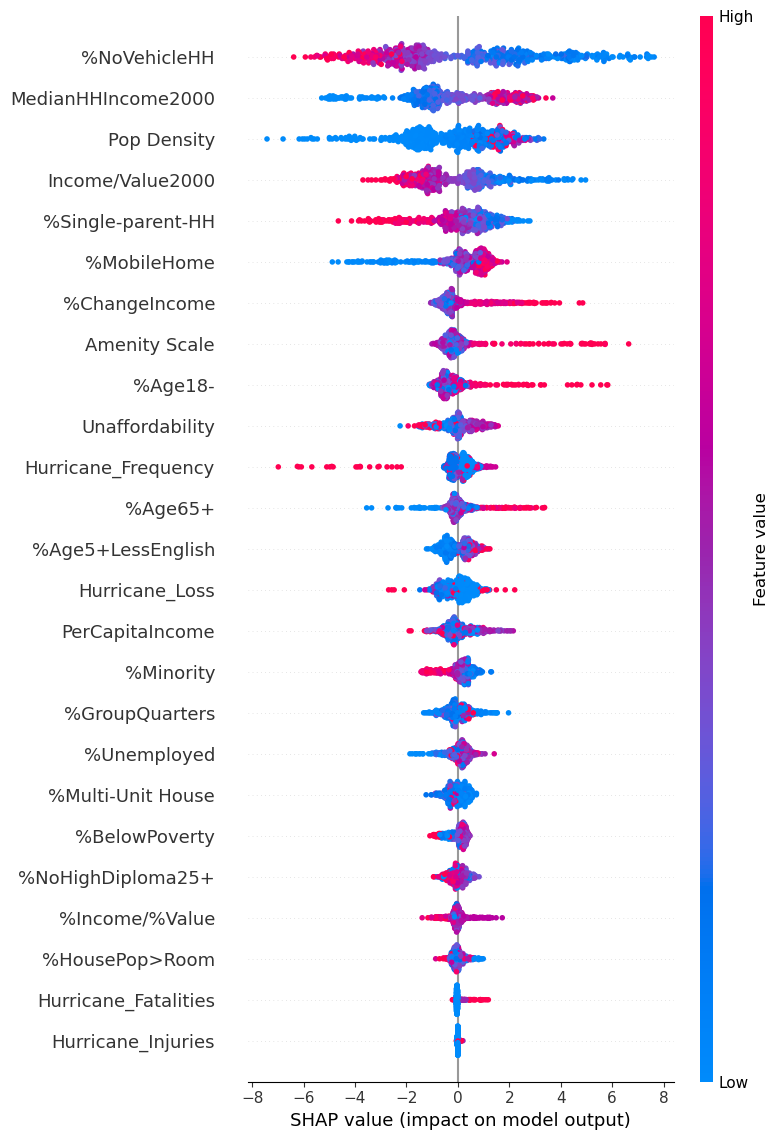

In [55]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train,max_display=30)

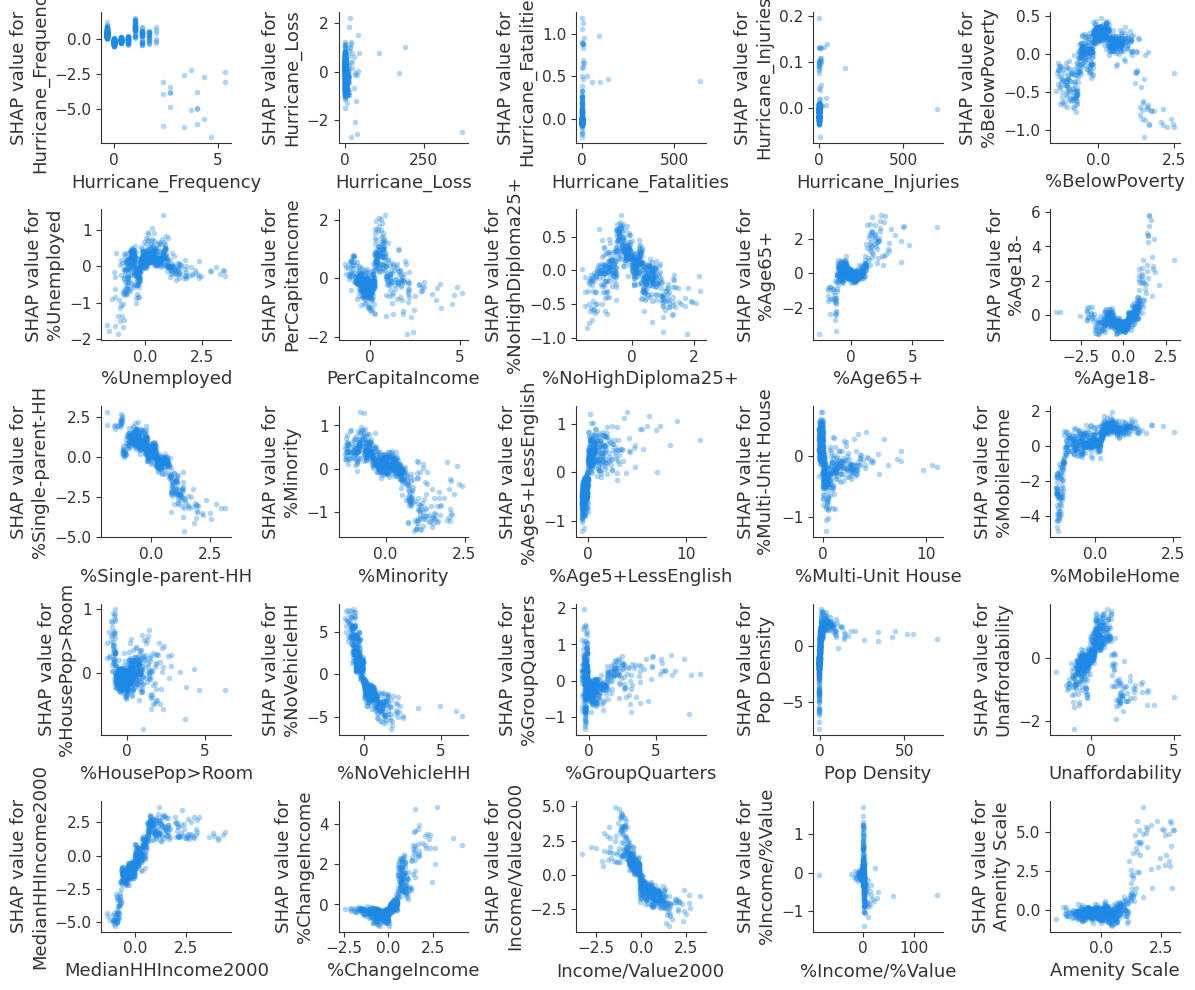

In [56]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Flood

## Without disaster variables

In [57]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Flood_Regression_data.csv")  # Adjust path if needed

In [58]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 02:32:27] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 02:32:27] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 02:32:27] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 02:32:27] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 02:32:27] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 02:32:27] {2393} INFO - Estimated sufficient time budget=4573s. Estimated necessary time budget=25s.
[flaml.automl.logger: 06-03 02:32:27] {2442} INFO -  at 0.5s,	estimator xgboost's best error=7.3311,	best estimator xgboost's best error=7.3311
[flaml.automl.logger: 06-03 02:32:27] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 02:32:27] {2442} INFO -  at 0.9s,	estimator lgbm's best error=7.3143,	best estimator lgbm's best error=7.3143
[flaml.automl.logger:

[flaml.automl.logger: 06-03 02:32:43] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 02:32:43] {2442} INFO -  at 16.4s,	estimator histgb's best error=5.1340,	best estimator histgb's best error=5.1340
[flaml.automl.logger: 06-03 02:32:43] {2258} INFO - iteration 35, current learner rf
[flaml.automl.logger: 06-03 02:32:44] {2442} INFO -  at 17.8s,	estimator rf's best error=5.5396,	best estimator histgb's best error=5.1340
[flaml.automl.logger: 06-03 02:32:44] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 06-03 02:32:45] {2442} INFO -  at 18.7s,	estimator histgb's best error=4.9793,	best estimator histgb's best error=4.9793
[flaml.automl.logger: 06-03 02:32:45] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 02:32:48] {2442} INFO -  at 21.4s,	estimator histgb's best error=4.8506,	best estimator histgb's best error=4.8506
[flaml.automl.logger: 06-03 02:32:48] {2258} INFO - iteration 38, current learne

[flaml.automl.logger: 06-03 02:33:55] {2442} INFO -  at 88.0s,	estimator extra_tree's best error=5.2240,	best estimator histgb's best error=4.8337
[flaml.automl.logger: 06-03 02:33:55] {2258} INFO - iteration 70, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:33:56] {2442} INFO -  at 89.0s,	estimator xgb_limitdepth's best error=5.2343,	best estimator histgb's best error=4.8337
[flaml.automl.logger: 06-03 02:33:56] {2258} INFO - iteration 71, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:33:56] {2442} INFO -  at 89.9s,	estimator xgb_limitdepth's best error=5.2343,	best estimator histgb's best error=4.8337
[flaml.automl.logger: 06-03 02:33:57] {2258} INFO - iteration 72, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:33:57] {2442} INFO -  at 90.8s,	estimator xgb_limitdepth's best error=5.2343,	best estimator histgb's best error=4.8337
[flaml.automl.logger: 06-03 02:33:57] {2258} INFO - iteration 73, current learner xgb_limitdepth
[flaml.autom

[flaml.automl.logger: 06-03 02:35:06] {2442} INFO -  at 159.1s,	estimator histgb's best error=4.8211,	best estimator histgb's best error=4.8211
[flaml.automl.logger: 06-03 02:35:06] {2258} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 06-03 02:35:08] {2442} INFO -  at 161.2s,	estimator extra_tree's best error=4.9486,	best estimator histgb's best error=4.8211
[flaml.automl.logger: 06-03 02:35:08] {2258} INFO - iteration 105, current learner xgboost
[flaml.automl.logger: 06-03 02:35:08] {2442} INFO -  at 161.9s,	estimator xgboost's best error=5.5895,	best estimator histgb's best error=4.8211
[flaml.automl.logger: 06-03 02:35:08] {2258} INFO - iteration 106, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:35:09] {2442} INFO -  at 162.7s,	estimator xgb_limitdepth's best error=5.0812,	best estimator histgb's best error=4.8211
[flaml.automl.logger: 06-03 02:35:09] {2258} INFO - iteration 107, current learner xgboost
[flaml.automl.logger: 06-03 02:35:10]

[flaml.automl.logger: 06-03 02:37:09] {2258} INFO - iteration 138, current learner catboost
[flaml.automl.logger: 06-03 02:37:24] {2442} INFO -  at 297.3s,	estimator catboost's best error=4.8167,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:37:24] {2258} INFO - iteration 139, current learner lgbm
[flaml.automl.logger: 06-03 02:37:25] {2442} INFO -  at 298.8s,	estimator lgbm's best error=4.9330,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:37:25] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 06-03 02:37:27] {2442} INFO -  at 300.5s,	estimator xgboost's best error=5.3007,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:37:27] {2258} INFO - iteration 141, current learner catboost
[flaml.automl.logger: 06-03 02:37:44] {2442} INFO -  at 316.9s,	estimator catboost's best error=4.8167,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:37:44] {2258} INFO 

[flaml.automl.logger: 06-03 02:40:26] {2258} INFO - iteration 173, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:40:27] {2442} INFO -  at 480.3s,	estimator xgb_limitdepth's best error=5.0812,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:40:27] {2258} INFO - iteration 174, current learner rf
[flaml.automl.logger: 06-03 02:40:29] {2442} INFO -  at 482.1s,	estimator rf's best error=4.9905,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:40:29] {2258} INFO - iteration 175, current learner rf
[flaml.automl.logger: 06-03 02:40:31] {2442} INFO -  at 484.9s,	estimator rf's best error=4.9904,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:40:31] {2258} INFO - iteration 176, current learner histgb
[flaml.automl.logger: 06-03 02:40:34] {2442} INFO -  at 487.6s,	estimator histgb's best error=4.8211,	best estimator catboost's best error=4.8167
[flaml.automl.logger: 06-03 02:40:34] {2258} INFO - iter

In [59]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")


Best estimator: catboost
Best config: {'early_stopping_rounds': 46, 'learning_rate': 0.0691299354906832, 'n_estimators': 8192}
Best validation loss: 4.781531525647748
Best Model Performance:
RMSE = 4.6824, MAE = 3.2856, ME = 0.2170, R² = 0.6830


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [60]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
5,histgb,4.615262,0.080468,3.260715,0.691988
6,catboost,4.623331,0.173264,3.261602,0.690910
0,xgboost,4.698704,-0.019867,3.363569,0.680749
4,lgbm,4.847578,0.090290,3.491789,0.660199
3,extra_tree,4.986644,-0.076079,3.533184,0.640423
2,rf,4.990387,-0.062823,3.572843,0.639883
1,xgb_limitdepth,5.124061,-0.060931,3.758196,0.620332


## With disaster

In [61]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 02:42:59] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 02:42:59] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 02:42:59] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 02:42:59] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 02:42:59] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 02:42:59] {2393} INFO - Estimated sufficient time budget=4575s. Estimated necessary time budget=25s.
[flaml.automl.logger: 06-03 02:42:59] {2442} INFO -  at 0.5s,	estimator xgboost's best error=7.3311,	best estimator xgboost's best error=7.3311
[flaml.automl.logger: 06-03 02:42:59] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 02:43:00] {2442} INFO -  at 0.8s,	estimator lgbm's best error=7.3143,	best estimator lgbm's best error=7.3143
[flaml.automl.logger:

[flaml.automl.logger: 06-03 02:43:14] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 02:43:17] {2442} INFO -  at 18.1s,	estimator histgb's best error=4.8313,	best estimator histgb's best error=4.8313
[flaml.automl.logger: 06-03 02:43:17] {2258} INFO - iteration 35, current learner rf
[flaml.automl.logger: 06-03 02:43:18] {2442} INFO -  at 19.6s,	estimator rf's best error=5.7718,	best estimator histgb's best error=4.8313
[flaml.automl.logger: 06-03 02:43:18] {2258} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 06-03 02:43:19] {2442} INFO -  at 20.2s,	estimator lgbm's best error=5.4849,	best estimator histgb's best error=4.8313
[flaml.automl.logger: 06-03 02:43:19] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 02:43:20] {2442} INFO -  at 21.1s,	estimator histgb's best error=4.8313,	best estimator histgb's best error=4.8313
[flaml.automl.logger: 06-03 02:43:20] {2258} INFO - iteration 38, current learner hi

[flaml.automl.logger: 06-03 02:44:34] {2442} INFO -  at 95.4s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 06-03 02:44:34] {2258} INFO - iteration 70, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:44:35] {2442} INFO -  at 96.4s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 06-03 02:44:35] {2258} INFO - iteration 71, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:44:36] {2442} INFO -  at 97.3s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 06-03 02:44:36] {2258} INFO - iteration 72, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 02:44:37] {2442} INFO -  at 98.2s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 06-03 02:44:37] {2258} INFO - iteration 73, current learner xgb_limitdepth
[flaml.a

[flaml.automl.logger: 06-03 02:45:44] {2258} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 06-03 02:45:44] {2442} INFO -  at 165.6s,	estimator extra_tree's best error=5.0029,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:45:44] {2258} INFO - iteration 105, current learner xgboost
[flaml.automl.logger: 06-03 02:45:46] {2442} INFO -  at 166.8s,	estimator xgboost's best error=5.4818,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:45:46] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 06-03 02:45:47] {2442} INFO -  at 168.5s,	estimator extra_tree's best error=4.9497,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:45:47] {2258} INFO - iteration 107, current learner rf
[flaml.automl.logger: 06-03 02:45:49] {2442} INFO -  at 170.3s,	estimator rf's best error=5.3672,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:45:49] {2258} INFO - it

[flaml.automl.logger: 06-03 02:47:24] {2258} INFO - iteration 139, current learner extra_tree
[flaml.automl.logger: 06-03 02:47:25] {2442} INFO -  at 266.6s,	estimator extra_tree's best error=4.9029,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:47:25] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 06-03 02:47:30] {2442} INFO -  at 271.5s,	estimator xgboost's best error=4.9163,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:47:30] {2258} INFO - iteration 141, current learner histgb
[flaml.automl.logger: 06-03 02:47:31] {2442} INFO -  at 272.5s,	estimator histgb's best error=4.8040,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:47:31] {2258} INFO - iteration 142, current learner xgboost
[flaml.automl.logger: 06-03 02:47:37] {2442} INFO -  at 277.8s,	estimator xgboost's best error=4.9163,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 06-03 02:47:37] {2258} INFO - 

[flaml.automl.logger: 06-03 02:49:54] {2258} INFO - iteration 174, current learner extra_tree
[flaml.automl.logger: 06-03 02:49:57] {2442} INFO -  at 417.9s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 06-03 02:49:57] {2258} INFO - iteration 175, current learner extra_tree
[flaml.automl.logger: 06-03 02:50:01] {2442} INFO -  at 422.6s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 06-03 02:50:01] {2258} INFO - iteration 176, current learner extra_tree
[flaml.automl.logger: 06-03 02:50:03] {2442} INFO -  at 424.4s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 06-03 02:50:03] {2258} INFO - iteration 177, current learner rf
[flaml.automl.logger: 06-03 02:50:10] {2442} INFO -  at 431.7s,	estimator rf's best error=4.9743,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 06-03 02:50:10] {2258} INF

In [62]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 702, 'max_leaves': 13, 'min_samples_leaf': 15, 'learning_rate': 0.052375124028920826, 'log_max_bin': 8, 'l2_regularization': 5.843252112061829, 'max_iter': 702}
Best validation loss: 4.791238603692614
Best Model Performance:
RMSE = 4.5473, MAE = 3.2718, ME = 0.0935, R² = 0.7010


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [63]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
6,catboost,4.478695,0.135921,3.167705,0.709946
5,histgb,4.569480,0.121174,3.243258,0.698068
0,xgboost,4.689230,0.042801,3.334561,0.682036
4,lgbm,4.793078,0.085260,3.453819,0.667796
1,xgb_limitdepth,4.934012,-0.046080,3.525825,0.647973
2,rf,4.993975,-0.091667,3.611512,0.639365
3,extra_tree,4.996446,-0.053048,3.547379,0.639008


In [64]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.7010
RMSE: 4.5473
MAE: 3.2718
ME (Mean Error): 0.0935


PermutationExplainer explainer: 2216it [16:49,  2.17it/s]                                                              


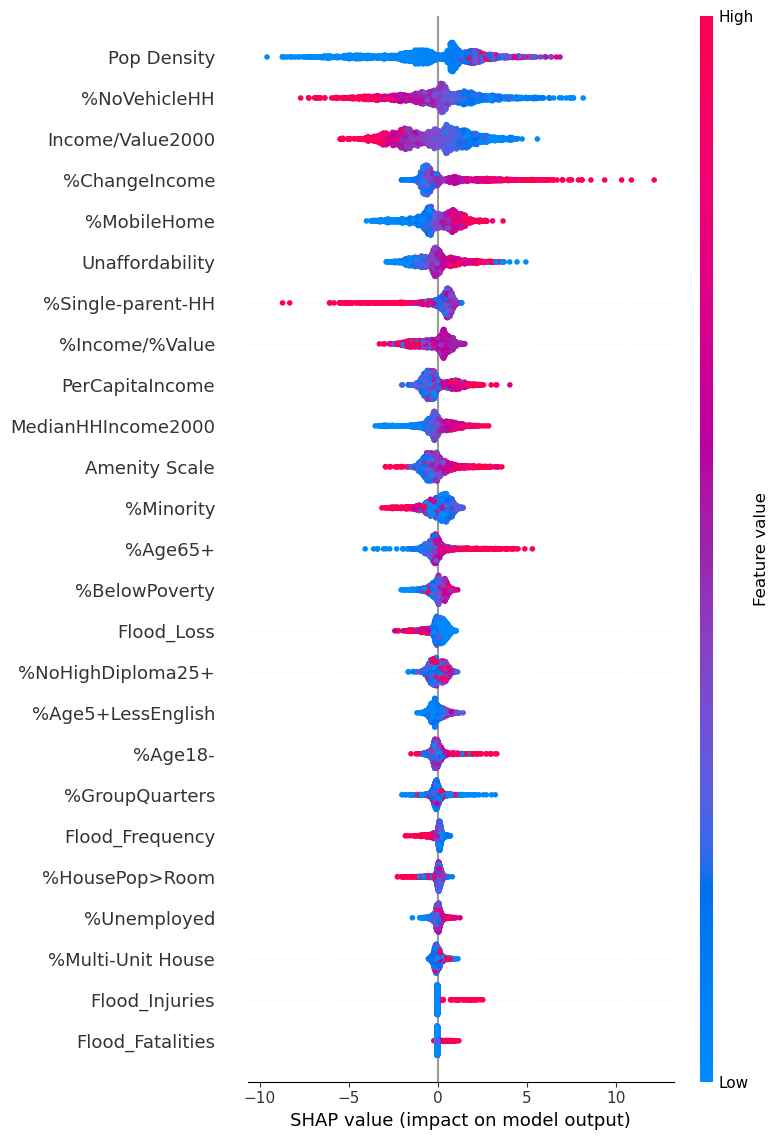

In [65]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train,max_display=30)

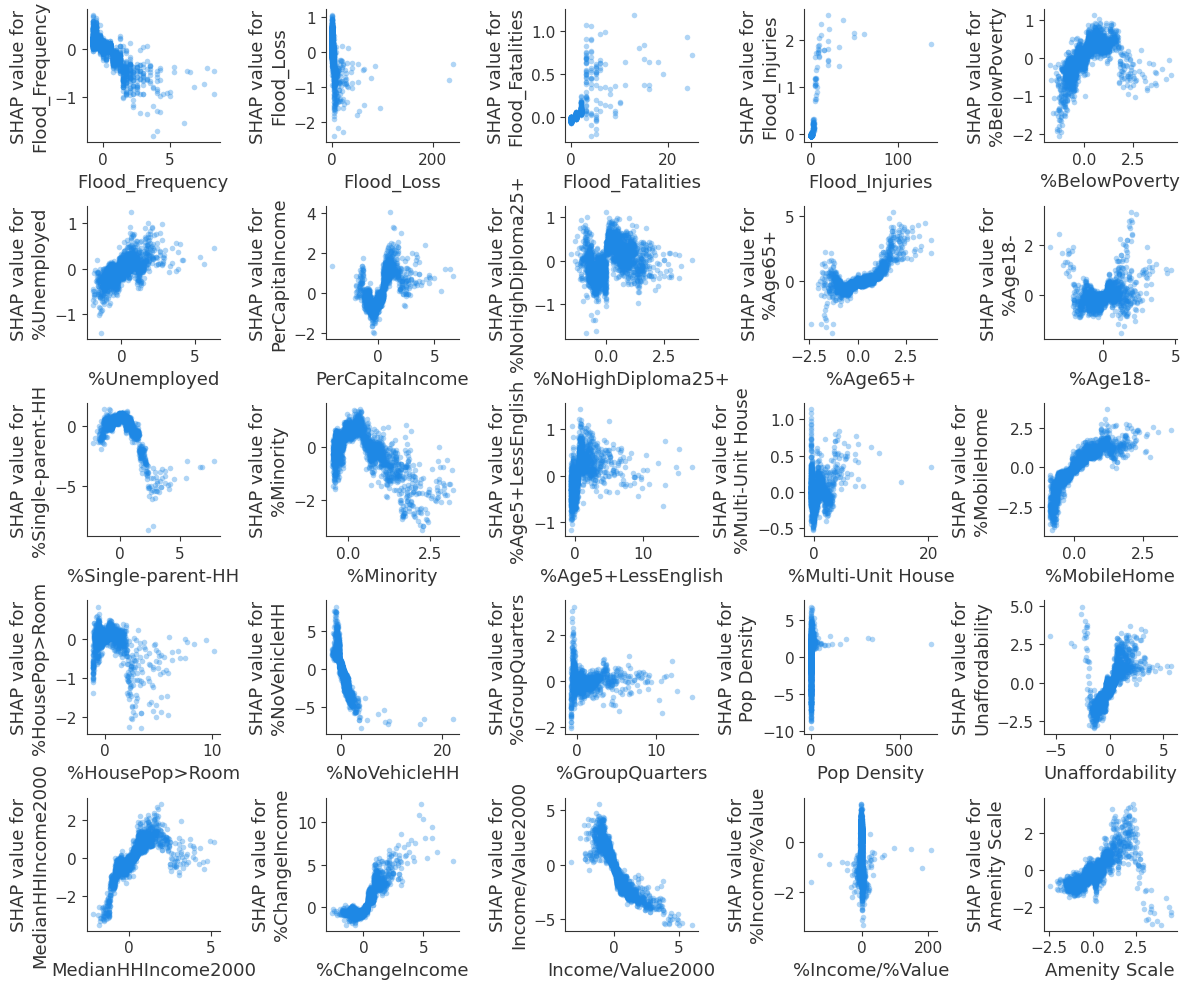

In [66]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Wildfire

## Without disaster

In [67]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Wildfire_Regression_data.csv")  # Adjust path if needed

In [68]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 03:10:22] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 03:10:22] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 03:10:22] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 03:10:22] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 03:10:22] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 03:10:22] {2393} INFO - Estimated sufficient time budget=4643s. Estimated necessary time budget=25s.
[flaml.automl.logger: 06-03 03:10:22] {2442} INFO -  at 0.5s,	estimator xgboost's best error=8.2479,	best estimator xgboost's best error=8.2479
[flaml.automl.logger: 06-03 03:10:22] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 03:10:22] {2442} INFO -  at 0.8s,	estimator lgbm's best error=8.2325,	best estimator lgbm's best error=8.2325
[flaml.automl.logger:

[flaml.automl.logger: 06-03 03:10:31] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 03:10:32] {2442} INFO -  at 9.9s,	estimator histgb's best error=5.9010,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:32] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 06-03 03:10:32] {2442} INFO -  at 10.4s,	estimator extra_tree's best error=7.2889,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:32] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 06-03 03:10:32] {2442} INFO -  at 10.6s,	estimator histgb's best error=5.9010,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:32] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 03:10:32] {2442} INFO -  at 10.8s,	estimator histgb's best error=5.9010,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:32] {2258} INFO - iteration 38,

[flaml.automl.logger: 06-03 03:10:48] {2442} INFO -  at 26.8s,	estimator xgboost's best error=6.2357,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:48] {2258} INFO - iteration 70, current learner rf
[flaml.automl.logger: 06-03 03:10:49] {2442} INFO -  at 27.3s,	estimator rf's best error=6.6879,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:49] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 06-03 03:10:49] {2442} INFO -  at 27.7s,	estimator histgb's best error=5.9010,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:49] {2258} INFO - iteration 72, current learner catboost
[flaml.automl.logger: 06-03 03:10:54] {2442} INFO -  at 32.2s,	estimator catboost's best error=6.2477,	best estimator histgb's best error=5.9010
[flaml.automl.logger: 06-03 03:10:54] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 06-03 03:10:54] {2442} INFO -  at 32.3s,	estimator hi

[flaml.automl.logger: 06-03 03:11:18] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 06-03 03:11:18] {2442} INFO -  at 56.2s,	estimator histgb's best error=5.8223,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:18] {2258} INFO - iteration 106, current learner rf
[flaml.automl.logger: 06-03 03:11:19] {2442} INFO -  at 57.2s,	estimator rf's best error=6.5090,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:19] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 06-03 03:11:19] {2442} INFO -  at 57.5s,	estimator histgb's best error=5.8223,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:19] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 06-03 03:11:19] {2442} INFO -  at 57.7s,	estimator histgb's best error=5.8223,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:19] {2258} INFO - iteration 109, current l

[flaml.automl.logger: 06-03 03:11:43] {2442} INFO -  at 81.6s,	estimator histgb's best error=5.8223,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:43] {2258} INFO - iteration 141, current learner rf
[flaml.automl.logger: 06-03 03:11:44] {2442} INFO -  at 82.8s,	estimator rf's best error=6.3301,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:44] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 06-03 03:11:45] {2442} INFO -  at 83.1s,	estimator histgb's best error=5.8223,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:45] {2258} INFO - iteration 143, current learner extra_tree
[flaml.automl.logger: 06-03 03:11:46] {2442} INFO -  at 84.0s,	estimator extra_tree's best error=6.6287,	best estimator histgb's best error=5.8223
[flaml.automl.logger: 06-03 03:11:46] {2258} INFO - iteration 144, current learner histgb
[flaml.automl.logger: 06-03 03:11:46] {2442} INFO -  at 84.3s,	estim

...

[flaml.automl.logger: 06-03 03:18:36] {2258} INFO - iteration 737, current learner histgb
[flaml.automl.logger: 06-03 03:18:37] {2442} INFO -  at 495.0s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:18:37] {2258} INFO - iteration 738, current learner histgb
[flaml.automl.logger: 06-03 03:18:37] {2442} INFO -  at 495.2s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:18:37] {2258} INFO - iteration 739, current learner histgb
[flaml.automl.logger: 06-03 03:18:37] {2442} INFO -  at 495.4s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:18:37] {2258} INFO - iteration 740, current learner histgb
[flaml.automl.logger: 06-03 03:18:37] {2442} INFO -  at 495.6s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:18:37] {2258} INFO - iteration 74

[flaml.automl.logger: 06-03 03:19:07] {2258} INFO - iteration 772, current learner xgboost
[flaml.automl.logger: 06-03 03:19:08] {2442} INFO -  at 526.6s,	estimator xgboost's best error=5.9670,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:08] {2258} INFO - iteration 773, current learner histgb
[flaml.automl.logger: 06-03 03:19:08] {2442} INFO -  at 526.8s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:08] {2258} INFO - iteration 774, current learner histgb
[flaml.automl.logger: 06-03 03:19:09] {2442} INFO -  at 527.0s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:09] {2258} INFO - iteration 775, current learner histgb
[flaml.automl.logger: 06-03 03:19:09] {2442} INFO -  at 527.2s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:09] {2258} INFO - iteration 

[flaml.automl.logger: 06-03 03:19:20] {2258} INFO - iteration 807, current learner histgb
[flaml.automl.logger: 06-03 03:19:20] {2442} INFO -  at 538.3s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:20] {2258} INFO - iteration 808, current learner extra_tree
[flaml.automl.logger: 06-03 03:19:21] {2442} INFO -  at 539.5s,	estimator extra_tree's best error=6.1500,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:21] {2258} INFO - iteration 809, current learner histgb
[flaml.automl.logger: 06-03 03:19:21] {2442} INFO -  at 539.7s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:21] {2258} INFO - iteration 810, current learner histgb
[flaml.automl.logger: 06-03 03:19:22] {2442} INFO -  at 539.9s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:22] {2258} INFO - iter

[flaml.automl.logger: 06-03 03:19:36] {2258} INFO - iteration 842, current learner histgb
[flaml.automl.logger: 06-03 03:19:36] {2442} INFO -  at 554.2s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:36] {2258} INFO - iteration 843, current learner extra_tree
[flaml.automl.logger: 06-03 03:19:39] {2442} INFO -  at 557.4s,	estimator extra_tree's best error=6.1500,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:39] {2258} INFO - iteration 844, current learner histgb
[flaml.automl.logger: 06-03 03:19:39] {2442} INFO -  at 557.7s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:39] {2258} INFO - iteration 845, current learner histgb
[flaml.automl.logger: 06-03 03:19:39] {2442} INFO -  at 557.9s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:19:39] {2258} INFO - iter

[flaml.automl.logger: 06-03 03:20:10] {2258} INFO - iteration 877, current learner xgboost
[flaml.automl.logger: 06-03 03:20:11] {2442} INFO -  at 589.2s,	estimator xgboost's best error=5.9670,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:20:11] {2258} INFO - iteration 878, current learner lgbm
[flaml.automl.logger: 06-03 03:20:14] {2442} INFO -  at 592.6s,	estimator lgbm's best error=5.9405,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:20:14] {2258} INFO - iteration 879, current learner histgb
[flaml.automl.logger: 06-03 03:20:14] {2442} INFO -  at 592.7s,	estimator histgb's best error=5.7031,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:20:14] {2258} INFO - iteration 880, current learner rf
[flaml.automl.logger: 06-03 03:20:16] {2442} INFO -  at 594.4s,	estimator rf's best error=6.0746,	best estimator histgb's best error=5.7031
[flaml.automl.logger: 06-03 03:20:16] {2258} INFO - iteration 881, current

In [69]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 42, 'max_leaves': 6, 'min_samples_leaf': 12, 'learning_rate': 0.181075597989201, 'log_max_bin': 7, 'l2_regularization': 0.11702064838283127, 'max_iter': 42}
Best validation loss: 5.703136283987787
Best Model Performance:
RMSE = 6.3474, MAE = 4.6238, ME = 0.4793, R² = 0.5957


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [70]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
6,catboost,6.421646,0.571792,4.479664,0.586158
3,extra_tree,6.645131,0.591496,4.571547,0.556851
2,rf,6.680064,0.528261,4.726138,0.552180
5,histgb,6.715805,0.807143,4.987341,0.547375
1,xgb_limitdepth,6.725019,0.544941,4.710970,0.546132
4,lgbm,6.794252,0.482309,4.896061,0.536739
0,xgboost,7.020054,0.390119,5.104658,0.505435


## With disaster

In [71]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 03:20:38] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 03:20:38] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 03:20:38] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 03:20:38] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 03:20:38] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 03:20:38] {2393} INFO - Estimated sufficient time budget=4495s. Estimated necessary time budget=24s.
[flaml.automl.logger: 06-03 03:20:38] {2442} INFO -  at 0.5s,	estimator xgboost's best error=8.2479,	best estimator xgboost's best error=8.2479
[flaml.automl.logger: 06-03 03:20:38] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 03:20:38] {2442} INFO -  at 0.8s,	estimator lgbm's best error=8.2325,	best estimator lgbm's best error=8.2325
[flaml.automl.logger:

[flaml.automl.logger: 06-03 03:20:48] {2442} INFO -  at 10.1s,	estimator extra_tree's best error=7.3915,	best estimator histgb's best error=5.9317
[flaml.automl.logger: 06-03 03:20:48] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 03:20:48] {2442} INFO -  at 10.4s,	estimator histgb's best error=5.9317,	best estimator histgb's best error=5.9317
[flaml.automl.logger: 06-03 03:20:48] {2258} INFO - iteration 35, current learner xgboost
[flaml.automl.logger: 06-03 03:20:49] {2442} INFO -  at 11.0s,	estimator xgboost's best error=6.5619,	best estimator histgb's best error=5.9317
[flaml.automl.logger: 06-03 03:20:49] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 06-03 03:20:49] {2442} INFO -  at 11.1s,	estimator histgb's best error=5.9317,	best estimator histgb's best error=5.9317
[flaml.automl.logger: 06-03 03:20:49] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 03:20:49] {2442} INFO -  at 11.4s,	est

[flaml.automl.logger: 06-03 03:21:08] {2258} INFO - iteration 69, current learner xgboost
[flaml.automl.logger: 06-03 03:21:09] {2442} INFO -  at 31.2s,	estimator xgboost's best error=6.2875,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 06-03 03:21:09] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 06-03 03:21:09] {2442} INFO -  at 31.6s,	estimator histgb's best error=5.9197,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 06-03 03:21:09] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 06-03 03:21:09] {2442} INFO -  at 31.9s,	estimator histgb's best error=5.9197,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 06-03 03:21:09] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 06-03 03:21:10] {2442} INFO -  at 32.1s,	estimator histgb's best error=5.8935,	best estimator histgb's best error=5.8935
[flaml.automl.logger: 06-03 03:21:10] {2258} INFO - iteration 73, curr

[flaml.automl.logger: 06-03 03:21:38] {2442} INFO -  at 60.6s,	estimator xgboost's best error=6.2875,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 06-03 03:21:38] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 06-03 03:21:39] {2442} INFO -  at 61.4s,	estimator histgb's best error=5.8305,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 06-03 03:21:39] {2258} INFO - iteration 106, current learner lgbm
[flaml.automl.logger: 06-03 03:21:41] {2442} INFO -  at 63.2s,	estimator lgbm's best error=6.0082,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 06-03 03:21:41] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 06-03 03:21:41] {2442} INFO -  at 63.6s,	estimator histgb's best error=5.8305,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 06-03 03:21:41] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 06-03 03:21:42] {2442} INFO -  at 64.8s,	estimato

[flaml.automl.logger: 06-03 03:22:16] {2258} INFO - iteration 140, current learner histgb
[flaml.automl.logger: 06-03 03:22:17] {2442} INFO -  at 99.9s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:22:17] {2258} INFO - iteration 141, current learner lgbm
[flaml.automl.logger: 06-03 03:22:19] {2442} INFO -  at 101.8s,	estimator lgbm's best error=6.0082,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:22:19] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 06-03 03:22:20] {2442} INFO -  at 102.5s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:22:20] {2258} INFO - iteration 143, current learner histgb
[flaml.automl.logger: 06-03 03:22:21] {2442} INFO -  at 103.9s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:22:21] {2258} INFO - iteration 144, cu

...

[flaml.automl.logger: 06-03 03:24:37] {2258} INFO - iteration 245, current learner rf
[flaml.automl.logger: 06-03 03:24:41] {2442} INFO -  at 243.1s,	estimator rf's best error=6.0517,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:24:41] {2258} INFO - iteration 246, current learner lgbm
[flaml.automl.logger: 06-03 03:24:42] {2442} INFO -  at 244.8s,	estimator lgbm's best error=5.9702,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:24:42] {2258} INFO - iteration 247, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 03:24:43] {2442} INFO -  at 245.5s,	estimator xgb_limitdepth's best error=6.2916,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:24:43] {2258} INFO - iteration 248, current learner histgb
[flaml.automl.logger: 06-03 03:24:44] {2442} INFO -  at 246.2s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:24:44] {2258} INFO - iteratio

[flaml.automl.logger: 06-03 03:25:42] {2258} INFO - iteration 280, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 03:25:43] {2442} INFO -  at 305.7s,	estimator xgb_limitdepth's best error=6.1294,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:25:43] {2258} INFO - iteration 281, current learner histgb
[flaml.automl.logger: 06-03 03:25:44] {2442} INFO -  at 306.7s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:25:44] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 06-03 03:25:45] {2442} INFO -  at 307.5s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:25:45] {2258} INFO - iteration 283, current learner xgboost
[flaml.automl.logger: 06-03 03:25:49] {2442} INFO -  at 311.8s,	estimator xgboost's best error=5.9524,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:25:49] {2258} I

[flaml.automl.logger: 06-03 03:26:54] {2258} INFO - iteration 315, current learner histgb
[flaml.automl.logger: 06-03 03:26:55] {2442} INFO -  at 377.2s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:26:55] {2258} INFO - iteration 316, current learner extra_tree
[flaml.automl.logger: 06-03 03:26:56] {2442} INFO -  at 378.3s,	estimator extra_tree's best error=6.2383,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:26:56] {2258} INFO - iteration 317, current learner histgb
[flaml.automl.logger: 06-03 03:26:57] {2442} INFO -  at 379.0s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:26:57] {2258} INFO - iteration 318, current learner histgb
[flaml.automl.logger: 06-03 03:26:58] {2442} INFO -  at 380.1s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:26:58] {2258} INFO - iter

[flaml.automl.logger: 06-03 03:28:25] {2442} INFO -  at 467.1s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:28:25] {2258} INFO - iteration 350, current learner histgb
[flaml.automl.logger: 06-03 03:28:26] {2442} INFO -  at 468.1s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:28:26] {2258} INFO - iteration 351, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 03:28:31] {2442} INFO -  at 473.0s,	estimator xgb_limitdepth's best error=5.9573,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:28:31] {2258} INFO - iteration 352, current learner histgb
[flaml.automl.logger: 06-03 03:28:32] {2442} INFO -  at 474.0s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:28:32] {2258} INFO - iteration 353, current learner histgb
[flaml.automl.logger: 06-03 03:28:32] {2442} INF

[flaml.automl.logger: 06-03 03:30:31] {2442} INFO -  at 593.1s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:30:31] {2258} INFO - iteration 385, current learner histgb
[flaml.automl.logger: 06-03 03:30:32] {2442} INFO -  at 594.6s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:30:32] {2258} INFO - iteration 386, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 03:30:35] {2442} INFO -  at 597.8s,	estimator xgb_limitdepth's best error=5.9573,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:30:35] {2258} INFO - iteration 387, current learner histgb
[flaml.automl.logger: 06-03 03:30:36] {2442} INFO -  at 598.9s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 06-03 03:30:36] {2258} INFO - iteration 388, current learner histgb
[flaml.automl.logger: 06-03 03:30:37] {2442} INF

In [72]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 435, 'max_leaves': 4, 'min_samples_leaf': 12, 'learning_rate': 0.04253334369952264, 'log_max_bin': 8, 'l2_regularization': 1.1695631397291768, 'max_iter': 435}
Best validation loss: 5.741357676209093
Best Model Performance:
RMSE = 6.2404, MAE = 4.4778, ME = 0.5648, R² = 0.6092


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [73]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
0,xgboost,6.358483,0.497544,4.675877,0.594259
5,histgb,6.455612,0.954999,4.647662,0.581768
6,catboost,6.458646,0.619777,4.591584,0.581375
1,xgb_limitdepth,6.561817,0.574614,4.696707,0.567894
4,lgbm,6.755099,0.757953,4.802684,0.542063
2,rf,6.779605,0.555926,4.834775,0.538734
3,extra_tree,6.914992,0.582620,4.838829,0.520128


In [74]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.6092
RMSE: 6.2404
MAE: 4.4778
ME (Mean Error): 0.5648


PermutationExplainer explainer: 437it [01:52,  3.53it/s]                                                               


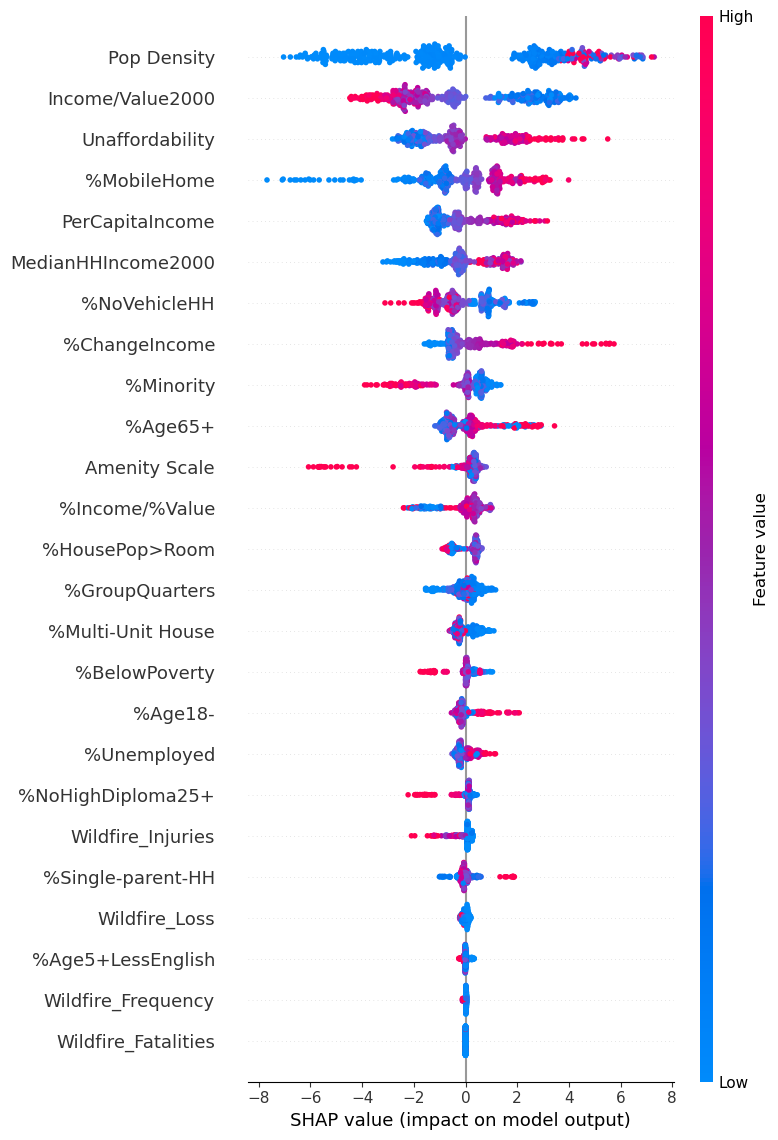

In [75]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train,max_display=30)

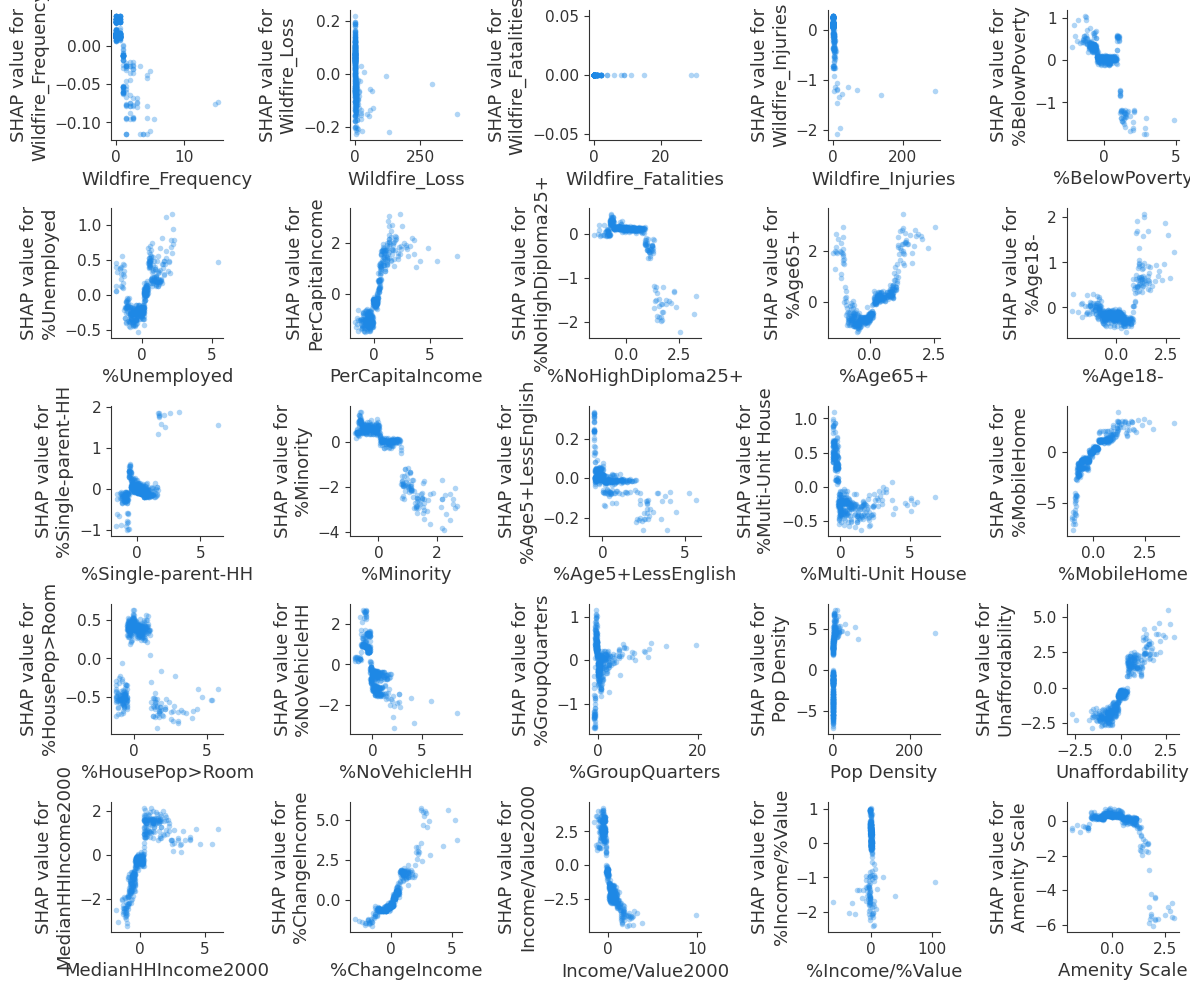

In [76]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Tornado

## Without disaster

In [77]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Tornado_Regression_data.csv")  # Adjust path if needed

In [78]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 03:32:48] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 03:32:48] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 03:32:48] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 03:32:48] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 03:32:48] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 03:32:49] {2393} INFO - Estimated sufficient time budget=4635s. Estimated necessary time budget=25s.
[flaml.automl.logger: 06-03 03:32:49] {2442} INFO -  at 0.5s,	estimator xgboost's best error=7.3648,	best estimator xgboost's best error=7.3648
[flaml.automl.logger: 06-03 03:32:49] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 03:32:49] {2442} INFO -  at 0.9s,	estimator lgbm's best error=7.3823,	best estimator xgboost's best error=7.3648
[flaml.automl.logg

[flaml.automl.logger: 06-03 03:33:04] {2442} INFO -  at 16.0s,	estimator rf's best error=5.9262,	best estimator histgb's best error=4.7571
[flaml.automl.logger: 06-03 03:33:04] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 03:33:08] {2442} INFO -  at 20.0s,	estimator histgb's best error=4.7427,	best estimator histgb's best error=4.7427
[flaml.automl.logger: 06-03 03:33:08] {2258} INFO - iteration 35, current learner catboost
[flaml.automl.logger: 06-03 03:33:14] {2442} INFO -  at 25.7s,	estimator catboost's best error=4.8622,	best estimator histgb's best error=4.7427
[flaml.automl.logger: 06-03 03:33:14] {2258} INFO - iteration 36, current learner rf
[flaml.automl.logger: 06-03 03:33:15] {2442} INFO -  at 26.5s,	estimator rf's best error=5.5869,	best estimator histgb's best error=4.7427
[flaml.automl.logger: 06-03 03:33:15] {2258} INFO - iteration 37, current learner extra_tree
[flaml.automl.logger: 06-03 03:33:16] {2442} INFO -  at 27.5s,	estimator ext

[flaml.automl.logger: 06-03 03:34:41] {2258} INFO - iteration 69, current learner extra_tree
[flaml.automl.logger: 06-03 03:34:42] {2442} INFO -  at 113.5s,	estimator extra_tree's best error=5.1306,	best estimator histgb's best error=4.6953
[flaml.automl.logger: 06-03 03:34:42] {2258} INFO - iteration 70, current learner xgboost
[flaml.automl.logger: 06-03 03:34:42] {2442} INFO -  at 114.1s,	estimator xgboost's best error=5.4745,	best estimator histgb's best error=4.6953
[flaml.automl.logger: 06-03 03:34:42] {2258} INFO - iteration 71, current learner extra_tree
[flaml.automl.logger: 06-03 03:34:44] {2442} INFO -  at 115.3s,	estimator extra_tree's best error=5.1306,	best estimator histgb's best error=4.6953
[flaml.automl.logger: 06-03 03:34:44] {2258} INFO - iteration 72, current learner extra_tree
[flaml.automl.logger: 06-03 03:34:44] {2442} INFO -  at 115.7s,	estimator extra_tree's best error=5.1306,	best estimator histgb's best error=4.6953
[flaml.automl.logger: 06-03 03:34:44] {225

[flaml.automl.logger: 06-03 03:36:11] {2442} INFO -  at 203.1s,	estimator xgboost's best error=5.4745,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:36:11] {2258} INFO - iteration 105, current learner lgbm
[flaml.automl.logger: 06-03 03:36:13] {2442} INFO -  at 205.0s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:36:13] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 06-03 03:36:15] {2442} INFO -  at 206.7s,	estimator extra_tree's best error=4.8889,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:36:15] {2258} INFO - iteration 107, current learner lgbm
[flaml.automl.logger: 06-03 03:36:17] {2442} INFO -  at 209.1s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:36:17] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 06-03 03:36:21] {2442} INFO -  at 212.7s,

[flaml.automl.logger: 06-03 03:37:44] {2258} INFO - iteration 139, current learner rf
[flaml.automl.logger: 06-03 03:37:46] {2442} INFO -  at 297.8s,	estimator rf's best error=4.8563,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:37:46] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 06-03 03:37:47] {2442} INFO -  at 298.3s,	estimator xgboost's best error=5.1718,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:37:47] {2258} INFO - iteration 141, current learner lgbm
[flaml.automl.logger: 06-03 03:37:50] {2442} INFO -  at 302.2s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:37:50] {2258} INFO - iteration 142, current learner xgb_limitdepth
[flaml.automl.logger: 06-03 03:37:51] {2442} INFO -  at 303.1s,	estimator xgb_limitdepth's best error=5.1143,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:37:51] {2258} INFO - iterat

[flaml.automl.logger: 06-03 03:39:58] {2258} INFO - iteration 174, current learner lgbm
[flaml.automl.logger: 06-03 03:39:59] {2442} INFO -  at 431.0s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:39:59] {2258} INFO - iteration 175, current learner lgbm
[flaml.automl.logger: 06-03 03:40:01] {2442} INFO -  at 433.0s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:40:01] {2258} INFO - iteration 176, current learner lgbm
[flaml.automl.logger: 06-03 03:40:05] {2442} INFO -  at 436.8s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:40:05] {2258} INFO - iteration 177, current learner rf
[flaml.automl.logger: 06-03 03:40:07] {2442} INFO -  at 438.7s,	estimator rf's best error=4.8563,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:40:07] {2258} INFO - iteration 178, current learner c

[flaml.automl.logger: 06-03 03:41:58] {2258} INFO - iteration 209, current learner histgb
[flaml.automl.logger: 06-03 03:41:59] {2442} INFO -  at 550.8s,	estimator histgb's best error=4.6866,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:41:59] {2258} INFO - iteration 210, current learner lgbm
[flaml.automl.logger: 06-03 03:42:03] {2442} INFO -  at 554.9s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:42:03] {2258} INFO - iteration 211, current learner extra_tree
[flaml.automl.logger: 06-03 03:42:05] {2442} INFO -  at 556.8s,	estimator extra_tree's best error=4.8253,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:42:05] {2258} INFO - iteration 212, current learner lgbm
[flaml.automl.logger: 06-03 03:42:06] {2442} INFO -  at 558.2s,	estimator lgbm's best error=4.8670,	best estimator histgb's best error=4.6866
[flaml.automl.logger: 06-03 03:42:06] {2258} INFO - iteration 21

In [79]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 159, 'max_leaves': 30, 'min_samples_leaf': 13, 'learning_rate': 0.06732448632119858, 'log_max_bin': 8, 'l2_regularization': 0.0598729414279302, 'max_iter': 159}
Best validation loss: 4.686616576078127
Best Model Performance:
RMSE = 4.8190, MAE = 3.1917, ME = 0.4527, R² = 0.7191


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [80]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
5,histgb,4.812086,0.480886,3.237990,0.719895
6,catboost,4.834853,0.482014,3.238312,0.717238
4,lgbm,4.951125,0.584833,3.308082,0.703475
0,xgboost,4.959477,0.473060,3.289626,0.702473
2,rf,5.069680,0.439614,3.364994,0.689104
3,extra_tree,5.113763,0.394844,3.374527,0.683674
1,xgb_limitdepth,5.201247,0.425056,3.552261,0.672758


## With disaster

In [81]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 06-03 03:43:12] {1728} INFO - task = regression
[flaml.automl.logger: 06-03 03:43:12] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 06-03 03:43:12] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-03 03:43:12] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 06-03 03:43:12] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 06-03 03:43:13] {2393} INFO - Estimated sufficient time budget=4762s. Estimated necessary time budget=26s.
[flaml.automl.logger: 06-03 03:43:13] {2442} INFO -  at 0.5s,	estimator xgboost's best error=7.3648,	best estimator xgboost's best error=7.3648
[flaml.automl.logger: 06-03 03:43:13] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-03 03:43:13] {2442} INFO -  at 0.9s,	estimator lgbm's best error=7.3823,	best estimator xgboost's best error=7.3648
[flaml.automl.logg

[flaml.automl.logger: 06-03 03:43:28] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 06-03 03:43:29] {2442} INFO -  at 16.8s,	estimator histgb's best error=4.8209,	best estimator histgb's best error=4.8209
[flaml.automl.logger: 06-03 03:43:29] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 06-03 03:43:30] {2442} INFO -  at 17.7s,	estimator extra_tree's best error=5.4999,	best estimator histgb's best error=4.8209
[flaml.automl.logger: 06-03 03:43:30] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 06-03 03:43:33] {2442} INFO -  at 20.2s,	estimator histgb's best error=4.7523,	best estimator histgb's best error=4.7523
[flaml.automl.logger: 06-03 03:43:33] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 06-03 03:43:33] {2442} INFO -  at 20.9s,	estimator histgb's best error=4.7523,	best estimator histgb's best error=4.7523
[flaml.automl.logger: 06-03 03:43:33] {2258} INFO - iteration 38

[flaml.automl.logger: 06-03 03:45:09] {2442} INFO -  at 116.2s,	estimator extra_tree's best error=5.1938,	best estimator histgb's best error=4.7237
[flaml.automl.logger: 06-03 03:45:09] {2258} INFO - iteration 70, current learner extra_tree
[flaml.automl.logger: 06-03 03:45:10] {2442} INFO -  at 117.5s,	estimator extra_tree's best error=5.1938,	best estimator histgb's best error=4.7237
[flaml.automl.logger: 06-03 03:45:10] {2258} INFO - iteration 71, current learner lgbm
[flaml.automl.logger: 06-03 03:45:14] {2442} INFO -  at 121.4s,	estimator lgbm's best error=4.8720,	best estimator histgb's best error=4.7237
[flaml.automl.logger: 06-03 03:45:14] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 06-03 03:45:19] {2442} INFO -  at 127.0s,	estimator histgb's best error=4.7037,	best estimator histgb's best error=4.7037
[flaml.automl.logger: 06-03 03:45:19] {2258} INFO - iteration 73, current learner lgbm
[flaml.automl.logger: 06-03 03:45:21] {2442} INFO -  at 128.7s

[flaml.automl.logger: 06-03 03:47:41] {2442} INFO -  at 269.0s,	estimator histgb's best error=4.6861,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 06-03 03:47:41] {2258} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 06-03 03:47:44] {2442} INFO -  at 271.4s,	estimator extra_tree's best error=4.8729,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 06-03 03:47:44] {2258} INFO - iteration 105, current learner xgboost
[flaml.automl.logger: 06-03 03:47:44] {2442} INFO -  at 272.0s,	estimator xgboost's best error=6.1348,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 06-03 03:47:44] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 06-03 03:47:49] {2442} INFO -  at 276.3s,	estimator extra_tree's best error=4.8729,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 06-03 03:47:49] {2258} INFO - iteration 107, current learner rf
[flaml.automl.logger: 06-03 03:47:50] {2442} INFO 

[flaml.automl.logger: 06-03 03:51:22] {2442} INFO -  at 489.7s,	estimator catboost's best error=4.7113,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 06-03 03:51:22] {2258} INFO - iteration 139, current learner histgb
[flaml.automl.logger: 06-03 03:51:32] {2442} INFO -  at 499.3s,	estimator histgb's best error=4.6515,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 06-03 03:51:32] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 06-03 03:51:32] {2442} INFO -  at 499.7s,	estimator xgboost's best error=5.7530,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 06-03 03:51:32] {2258} INFO - iteration 141, current learner lgbm
[flaml.automl.logger: 06-03 03:51:39] {2442} INFO -  at 506.7s,	estimator lgbm's best error=4.7724,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 06-03 03:51:39] {2258} INFO - iteration 142, current learner xgboost
[flaml.automl.logger: 06-03 03:51:40] {2442} INFO -  at 507.3s,

In [82]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 1808, 'max_leaves': 14, 'min_samples_leaf': 6, 'learning_rate': 0.00926826560541849, 'log_max_bin': 7, 'l2_regularization': 0.06224282597597983, 'max_iter': 1808}
Best validation loss: 4.651463246227854
Best Model Performance:
RMSE = 4.8682, MAE = 3.2160, ME = 0.3964, R² = 0.7133


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [83]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\skle

,estimator,rmse,me,mae,r2
5,histgb,4.799884,0.437421,3.193408,0.721314
6,catboost,4.917090,0.503641,3.276431,0.707537
4,lgbm,5.039242,0.484977,3.377796,0.692826
2,rf,5.113750,0.404239,3.472813,0.683675
1,xgb_limitdepth,5.118095,0.373792,3.484310,0.683138
3,extra_tree,5.159446,0.379104,3.402772,0.677997
0,xgboost,5.474348,0.411897,3.649833,0.637491


In [84]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.7133
RMSE: 4.8682
MAE: 3.2160
ME (Mean Error): 0.3964


PermutationExplainer explainer: 1810it [34:51,  1.16s/it]                                                              


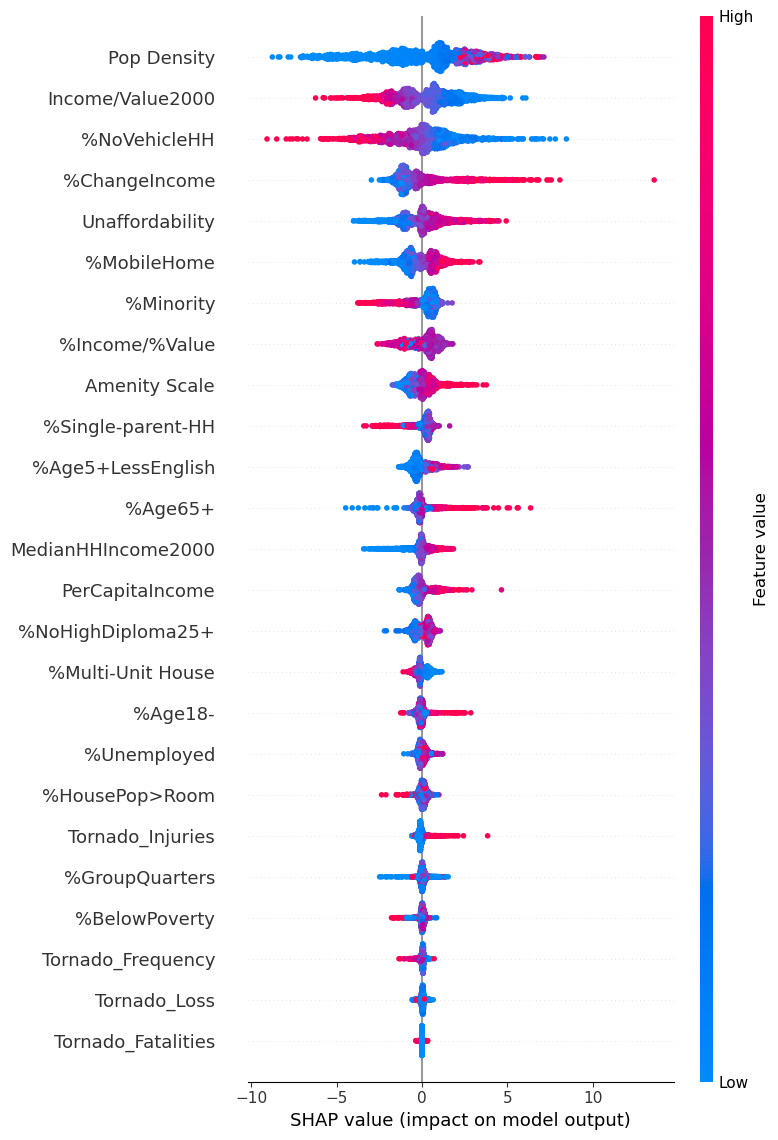

In [85]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train,max_display=30)

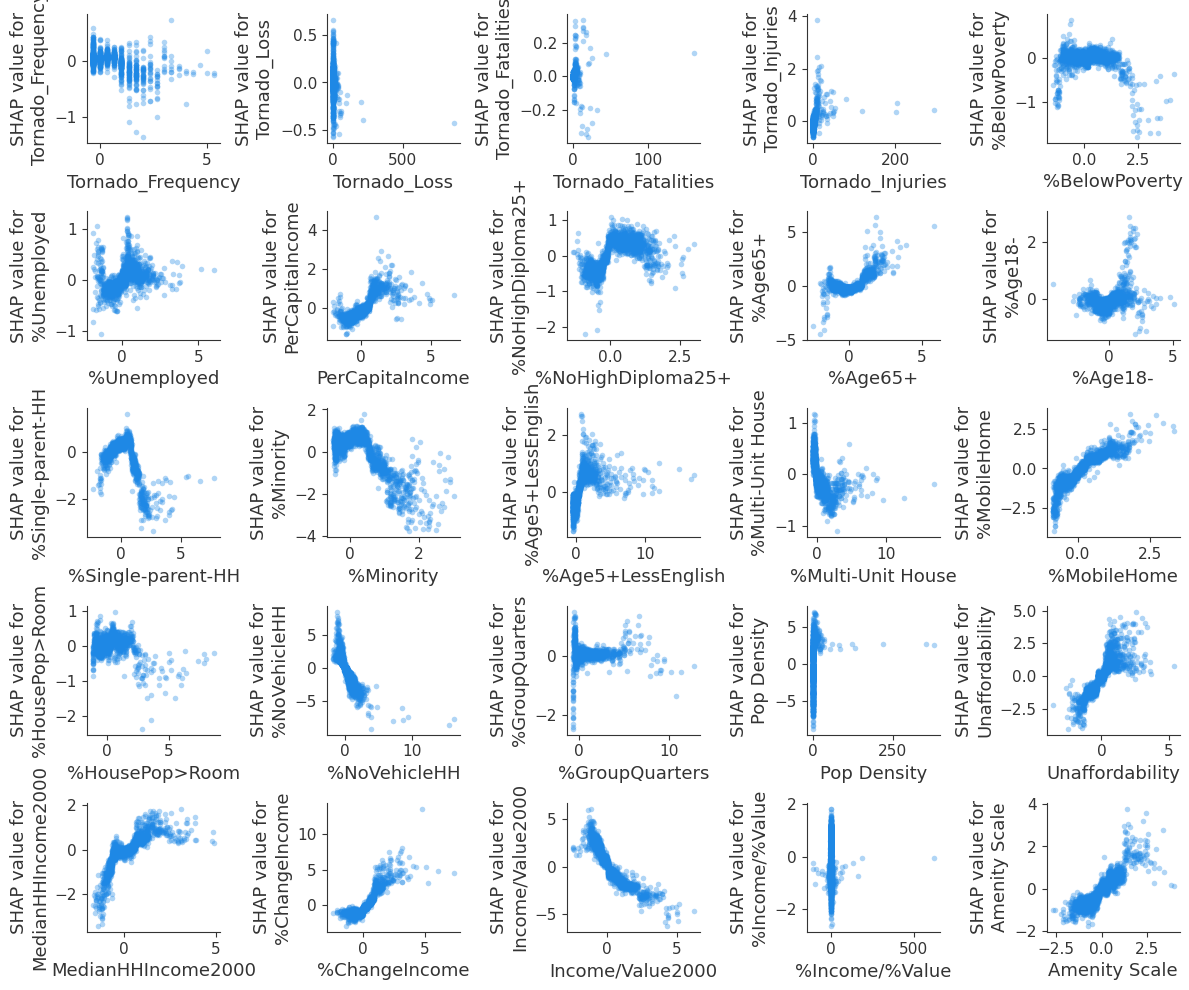

In [86]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()